Test connectivity metrics from frites

In [1]:
%load_ext autoreload
%autoreload 2
%matplotlib inline
import numpy as np
import fmatoolbox as fma
import regions as rg
import xarray as xr
import itertools
import concurrent.futures
import os
import matplotlib.pyplot as plt
import scipy as sp
import ISRUtilities as isru

1. test fetching data from a session

In [ ]:
def _periRippleRegActivityOLD(session,regs=None,n_shuffle=0):
    # get region firing rates and their correltion around ripple times as (ripples, regions, times, shuffle) XArray
    # 'shuffle' coordinate is False iff corresponding data values are real

    R = rg.data.Regions(session,states=['sws'],events=['ripples'])
    regs = R.ids if regs is None else np.array(regs)
    
    # restrict in nREM to use shuffled ripples
    ripple_peaks = fma.general.restrict(R.eventInfo('ripples')[:,2],R.eventIntervals('sws'),shift=True)
    shuffled_rip = np.zeros((ripple_peaks.size,n_shuffle))
    for i in range(n_shuffle):
        shuffled_rip[:,i] = fma.general.shuffleEvents(ripple_peaks).ravel()
    firing_rate = fma.general.restrict(R.firingRate(norm=True),R.eventIntervals('sws'),shift=True)

    # real data firing rates
    n_bins = 151
    peth = {}
    statistic_fr = {}
    fr_data = np.full((len(ripple_peaks),len(regs),n_bins,int(bool(n_shuffle))+1),np.nan)
    r_ind = []
    for i, r in enumerate(R.ids):
        r_ind.append(np.where(regs==r)[0])
        if r in regs:
            peth[r], t, _ = fma.analysis.PETH(firing_rate[:,[0,i+1]],ripple_peaks,n_bins=n_bins)
            fr_data[:,r_ind[i][0],:,0] = peth[r]
            statistic_fr[r] = maxDeviation(peth[r])
    # dFC
    reg_pairs = list(itertools.combinations(regs,2))
    window = int(.25 // (t[1]-t[0])) # 0.25 s
    stride = int(.02 // (t[1]-t[0])) # 20 ms step between each window
    dfc = [spearmanRowCorr(peth[rp[0]],peth[rp[1]],window,stride=stride) for rp in reg_pairs]
    statistic_dfc = [maxDeviation(d) for d in dfc]
    sl_time = np.interp(np.arange(0,t.size-window+1,stride) + (window-1)/2, np.arange(t.size), t) # center of each window

    # surrogate
    statistic_fr_sh = {r: [] for r in regs}
    statistic_dfc_sh = [[] for rp in reg_pairs]
    for j in range(n_shuffle):
        
        # surrogate ripple PETHs
        peth_sh = {}
        for i, r in enumerate(R.ids):
            if r in regs:
                peth_sh[r] = fma.analysis.PETH(firing_rate[:,[0,i+1]],shuffled_rip[:,j],n_bins=n_bins)[0]
                statistic_fr_sh[r].append(maxDeviation(peth_sh[r]))
                if j == 0:
                    fr_data[:,r_ind[i][0],:,j+1] = peth_sh[r]
        
        # surrogate dfc statistics
        dfc_sh = [spearmanRowCorr(peth_sh[rp[0]],peth_sh[rp[1]],window,stride=stride) for rp in reg_pairs]
        for i, rp in enumerate(reg_pairs):
            statistic_dfc_sh[i].append(maxDeviation(dfc_sh[i]))
        if j == 0:
            dfc = [dfc,dfc_sh]

    fr_data = xr.DataArray(fr_data,dims=('ripple','region','time','shuffle'),coords={'region': regs, 'time': t, 'shuffle': [False] + [True]*int(bool(n_shuffle))})
    fr_data.attrs['p_val'] = np.array([fma.analysis.MCpValue(statistic_fr_sh[r],statistic_fr[r]).squeeze() for r in regs])

    dfc_data = xr.DataArray(np.array(dfc,ndmin=4),dims=('shuffle','region','ripple','time'),coords={'shuffle': [False] + [True]*int(bool(n_shuffle)),
                            'region': [f'{rp[0]}-{rp[1]}' for rp in reg_pairs], 'time': sl_time})
    dfc_data.attrs['p_val'] = np.array([fma.analysis.MCpValue(statistic_dfc_sh[i],statistic_dfc[i]).squeeze() for i, rp in enumerate(reg_pairs)])
            

    return fr_data, dfc_data

In [2]:
# functions to compute row-wise correlation

def spearmanRank(x):
    return np.argsort(np.argsort(x,axis=-1),axis=-1).astype(np.float64)

def spearmanRowCorr(a,b,window,stride=1):

    # define windows with strides (should be read-only!)
    wa = np.lib.stride_tricks.sliding_window_view(a,window,axis=1)[:,::stride,:]
    wb = np.lib.stride_tricks.sliding_window_view(b,window,axis=1)[:,::stride,:]

    # rank along last axis (inside windows)
    ra = spearmanRank(wa)
    rb = spearmanRank(wb)

    # row-wise correlations: cov(r1,r2) / (std(r1)*std(r2))
    ra -= ra.mean(axis=-1,keepdims=True)
    rb -= rb.mean(axis=-1,keepdims=True)
    num = np.sum(ra*rb,axis=-1)
    den = np.sqrt(np.sum(ra**2, axis=-1) * np.sum(rb**2, axis=-1))

    return num / den

# functions to compute statistics

def maxDeviation(x):
    return np.abs(x-np.nanmean(x)).max()

def centralMean(x,w=.25):
    return np.mean(x[int((1-w)*len(x)/2) : int((1+w)*len(x)/2)])

def centralDeviation(x,w=.25):
    return np.abs(np.mean(x[int((1-w)*len(x)/2) : int((1+w)*len(x)/2)]) - np.nanmean(x))

def workerStatistics(firing_rate,ripples,col_ind,reg_pairs,n_bins,window,stride,return_data=False):

    # surrogate ripple PETHs
    peth = []
    peth_avrg = []
    statistic_fr = []
    for r in col_ind:
        peth.append(fma.analysis.PETH(firing_rate[:,[0,r+1]],ripples,n_bins=n_bins)[0])
        peth_avrg.append(np.nanmean(peth[-1],axis=0))
        statistic_fr.append(maxDeviation(peth_avrg[-1]))

    # surrogate dfc statistics
    dfc = [spearmanRowCorr(peth[rp[0]],peth[rp[1]],window,stride=stride) for rp in reg_pairs]
    dfc_avrg = [np.nanmean(d,axis=0) for d in dfc]
    statistic_dfc = [centralDeviation(d) for d in dfc_avrg]

    if return_data:
        return peth, dfc, statistic_fr, statistic_dfc
    return peth_avrg, dfc_avrg, statistic_fr, statistic_dfc

# function called per session

def _periRippleRegActivity(session,regs=None,n_shuffle=0):
    # get region firing rates and their correlation around ripple times as (ripples, regions, times, shuffle) XArray
    # 'shuffle' coordinate is False iff corresponding data values are real

    R = rg.data.Regions(session,states=['sws'],events=['ripples'])
    regs = R.ids if regs is None else np.array(regs)

    # find regs in region ids
    fr_ind = [int(np.where(R.ids==r)[0][0]) if r in R.ids else None for r in regs] # fr_ind[i] is index of regs[i] in R.ids
    reg_pair_idx = list(itertools.combinations(range(len(regs)),2))
    
    # restrict in nREM to use shuffled ripples
    ripple_peaks = fma.general.restrict(R.eventInfo('ripples')[:,2],R.eventIntervals('sws'),shift=True)
    shuffled_rip = np.zeros((ripple_peaks.size,n_shuffle))
    for i in range(n_shuffle):
        shuffled_rip[:,i] = fma.general.shuffleEvents(ripple_peaks).ravel()
    firing_rate = fma.general.restrict(R.firingRate(norm=True),R.eventIntervals('sws'),shift=True)

    # observed statistics
    n_bins = 151
    t = fma.analysis.PETH([[0,0]],[0],n_bins=n_bins)[1]
    window = int(.25 // (t[1]-t[0])) # 0.25 s
    stride = int(.02 // (t[1]-t[0])) # 20 ms step between each window
    sl_time = np.interp(np.arange(0,t.size-window+1,stride) + (window-1)/2, np.arange(t.size), t) # center of each window
    fr_data, dfc_data, statistic_fr, statistic_dfc = workerStatistics(firing_rate,ripple_peaks,fr_ind,reg_pair_idx,n_bins,window,stride,return_data=True)

    # surrogate statistics
    if n_shuffle:
        # store one shuffled example
        peth_sh, dfc_sh, _, _ = workerStatistics(firing_rate,shuffled_rip[:,0],fr_ind,reg_pair_idx,n_bins,window,stride,return_data=True)
        fr_data = [fr_data,peth_sh]
        dfc_data = [dfc_data,dfc_sh]
        statistic_fr_sh = np.full((1,len(regs)),np.nan)
        statistic_dfc_sh = np.full((1,len(regs)),np.nan)
        if n_shuffle > 1:
            def worker(j):
                # closure of variables shared between workes + j indexes worker-specific columns
                return workerStatistics(firing_rate,shuffled_rip[:,j],fr_ind,reg_pair_idx,n_bins,window,stride)
            with concurrent.futures.ThreadPoolExecutor(max_workers=int(os.cpu_count()*3/4)) as executor:
                results = list(executor.map(worker, range(n_shuffle)))
            peth_sh_avrg = np.array([r[0] for r in results])
            dfc_sh_avrg = np.array([r[1] for r in results])
            statistic_fr_sh = np.array([r[2] for r in results])
            statistic_dfc_sh = np.array([r[3] for r in results])

    fr_data = xr.DataArray(np.array(fr_data,ndmin=4),dims=('shuffle','region','ripple','time'),coords={'shuffle': [False] + [True]*int(bool(n_shuffle)),
                                                                                                       'region': regs, 'time': t})
    fr_data.attrs['p_val'] = np.array([fma.analysis.MCpValue(statistic_fr_sh[:,i],statistic_fr[i]).squeeze() for i in range(len(regs))])

    dfc_data = xr.DataArray(np.array(dfc_data,ndmin=4),dims=('shuffle','region','ripple','time'),coords={'shuffle': [False] + [True]*int(bool(n_shuffle)),
                            'region': [f'{regs[rp[0]]}-{regs[rp[1]]}' for rp in reg_pair_idx], 'time': sl_time})
    dfc_data.attrs['p_val'] = np.array([fma.analysis.MCpValue(statistic_dfc_sh[:,i],statistic_dfc[i]).squeeze() for i in range(len(regs))])

    peth_sh_avrg = xr.DataArray(peth_sh_avrg,dims=('shuffle','region','time'),coords={'region': regs, 'time': t})
    dfc_sh_avrg = xr.DataArray(dfc_sh_avrg,dims=('shuffle','region','time'),coords={'region': regs, 'time': sl_time})
            
    return fr_data, dfc_data, peth_sh_avrg, dfc_sh_avrg

In [3]:
regs = ['hpc','nr','pfc']
batch_file = '/mnt/hubel-data-103/Pietro/Data/BatchFiles/IS_states.batch'

In [4]:
session = fma.data.readBatchFile(batch_file)[0][3] # 15 is a good example
print(f'session: {session}')
fr_xdata, dfc_xdata, _, _ = _periRippleRegActivity(session,regs,n_shuffle=10)

session: /mnt/hubel-data-131/perceval/Rat003_20231215/Rat003_20231215.xml


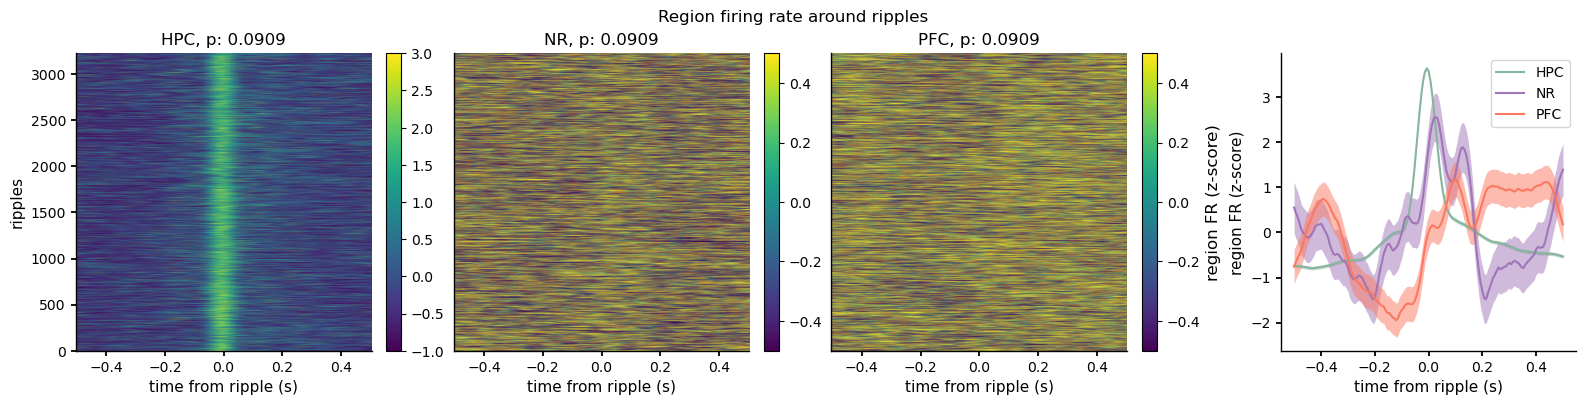

In [8]:
# NR: slight depression after ripple, PFC: same but before
do_surrogate = 0
fig, axs = fma.plotting.makeFigure('Region firing rate around ripples'+bool(do_surrogate)*', surrogate',[1,4],[40,10])
vmin = [-1,-.5,-.5]
vmax = [3,.5,.5]
#sort_ind = fr_xdata.sel(region='hpc').isel(shuffle=do_surrogate).argmax(dim='time')
for i, r in enumerate(fr_xdata['region']):
    # PETH matrix
    reg_data = fr_xdata.sel(region=r).isel(shuffle=do_surrogate)
    im = fma.plotting.plotColorMap(reg_data.values,vmin=vmin[i],vmax=vmax[i],zscore=1,ax=axs[i],x=reg_data['time'])
    cb = plt.colorbar(im)
    axs[i].set_title(f'{r.item().upper()}, p: {fr_xdata.attrs['p_val'][i]:.4f}')
    axs[i].set_xlabel('time from ripple (s)')
    # average PETH
    fma.plotting.semPlot(fr_xdata['time'],reg_data,zscore=True,color=isru.paperColors(i),label=str(r.item().upper()),ax=axs[-1])
    if i != 0:
        axs[i].set_yticks([])
cb.set_label('region FR (z-score)',fontsize=12)
axs[0].set_ylabel('ripples')
axs[-1].set_xlabel('time from ripple (s)'), axs[-1].set_ylabel('region FR (z-score)'), axs[-1].legend();

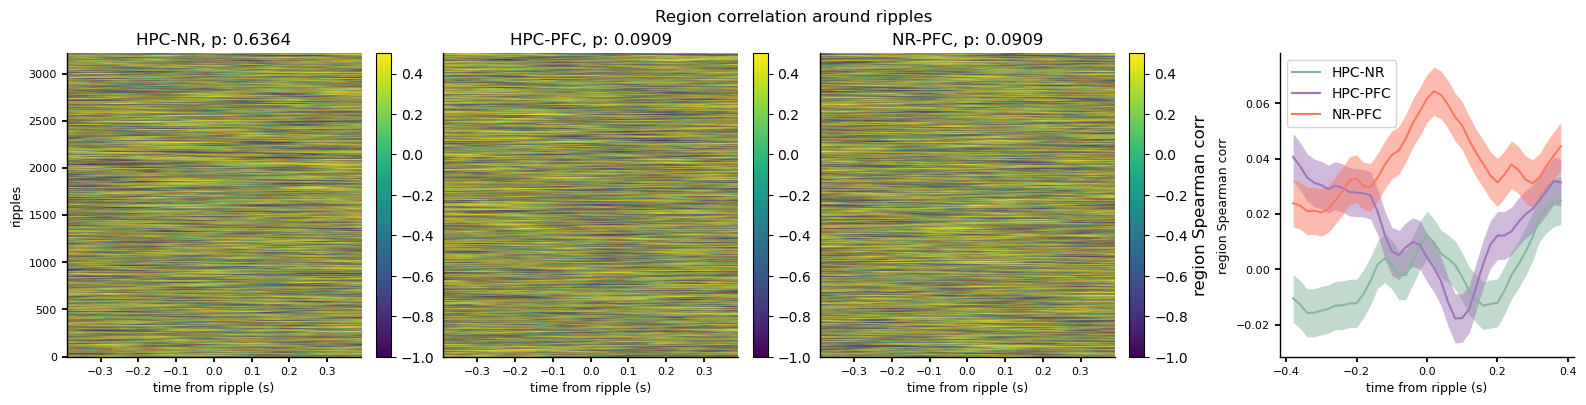

In [5]:
# NR: slight depression after ripple, PFC: same but before
do_surrogate = 0
fig, axs = fma.plotting.makeFigure('Region correlation around ripples'+bool(do_surrogate)*', surrogate',[1,4],[40,10])
vmin = [-1,-1,-1]
vmax = [.5,.5,.5]
sort_ind = dfc_xdata.sel(region='hpc-nr').isel(shuffle=do_surrogate).argmax(dim='time')
for i, r in enumerate(dfc_xdata['region']):
    # PETH matrix
    reg_data = dfc_xdata.sel(region=r).isel(shuffle=do_surrogate)
    im = fma.plotting.plotColorMap(reg_data.values,vmin=vmin[i],vmax=vmax[i],zscore=1,ax=axs[i],x=reg_data['time'])
    cb = plt.colorbar(im)
    axs[i].set_title(f'{r.item().upper()}, p: {dfc_xdata.attrs['p_val'][i]:.4f}')
    axs[i].set_xlabel('time from ripple (s)')
    # average PETH
    fma.plotting.semPlot(dfc_xdata['time'],reg_data,zscore=False,color=isru.paperColors(i),label=str(r.item().upper()),ax=axs[-1])
    if i != 0:
        axs[i].set_yticks([])
cb.set_label('region Spearman corr',fontsize=12)
axs[0].set_ylabel('ripples')
axs[-1].set_xlabel('time from ripple (s)'), axs[-1].set_ylabel('region Spearman corr'), axs[-1].legend();

2. firing rate grand average

In [4]:
fr_data, dfc_data, peth_sh_avrg, dfc_sh_avrg = fma.data.runBatch(batch_file,_periRippleRegActivity,[[regs]],[{'n_shuffle': 1000}])


Starting Batch, 2026-03-06 12:10:49.227830 

Batch progress: /mnt/hubel-data-131/perceval/Rat003_20231212/Rat003_20231212.xml, 1 out of 31

Batch progress: /mnt/hubel-data-131/perceval/Rat003_20231213/Rat003_20231213.xml, 2 out of 31

Batch progress: /mnt/hubel-data-131/perceval/Rat003_20231214/Rat003_20231214.xml, 3 out of 31

Batch progress: /mnt/hubel-data-131/perceval/Rat003_20231215/Rat003_20231215.xml, 4 out of 31

Batch progress: /mnt/hubel-data-131/perceval/Rat003_20231218/Rat003_20231218.xml, 5 out of 31

Batch progress: /mnt/hubel-data-131/perceval/Rat003_20231219/Rat003_20231219.xml, 6 out of 31

Batch progress: /mnt/hubel-data-131/perceval/Rat003_20231221/Rat003_20231221.xml, 7 out of 31

Batch progress: /mnt/hubel-data-131/perceval/Rat003_20231222/Rat003_20231222.xml, 8 out of 31

Batch progress: /mnt/hubel-data-131/perceval/Rat003_20231223/Rat003_20231223.xml, 9 out of 31

Batch progress: /mnt/hubel-data-131/perceval/Rat003_20231224/Rat003_20231224.xml, 10 out of 31

Bat

In [5]:
# concatenate data
fr_cat = xr.concat([d for d in fr_data],dim='ripple')
fr_avrg = xr.concat([d.mean(dim='ripple') for d in fr_data],dim='session')
fr_sh = xr.concat([d for d in peth_sh_avrg],dim='session')
dfc_cat = xr.concat([d for d in dfc_data],dim='ripple')
dfc_avrg = xr.concat([d.mean(dim='ripple') for d in dfc_data],dim='session')
dfc_sh = xr.concat([d for d in dfc_sh_avrg],dim='session')
# grand-average statistical test
statistic_fr = np.apply_along_axis(maxDeviation,1,fr_avrg.sel(shuffle=False).mean(dim='session').values)
statistic_dfc = np.apply_along_axis(maxDeviation,1,dfc_avrg.sel(shuffle=False).mean(dim='session').values)
statistic_fr_sh = np.apply_along_axis(maxDeviation,2,fr_sh.mean(dim='session').values)
statistic_dfc_sh = np.apply_along_axis(maxDeviation,2,dfc_sh.mean(dim='session').values)
pval_fr = {regs[i]: p for i, p in enumerate(fma.analysis.MCpValue(statistic_fr_sh,statistic_fr))}
pval_dfc = {dfc_cat.coords['region'][i].item(): p for i, p in enumerate(fma.analysis.MCpValue(statistic_dfc_sh,statistic_dfc))}

HPC-NR: 0.020000000000000073 s
HPC-PFC: 0.09333333333333332 s


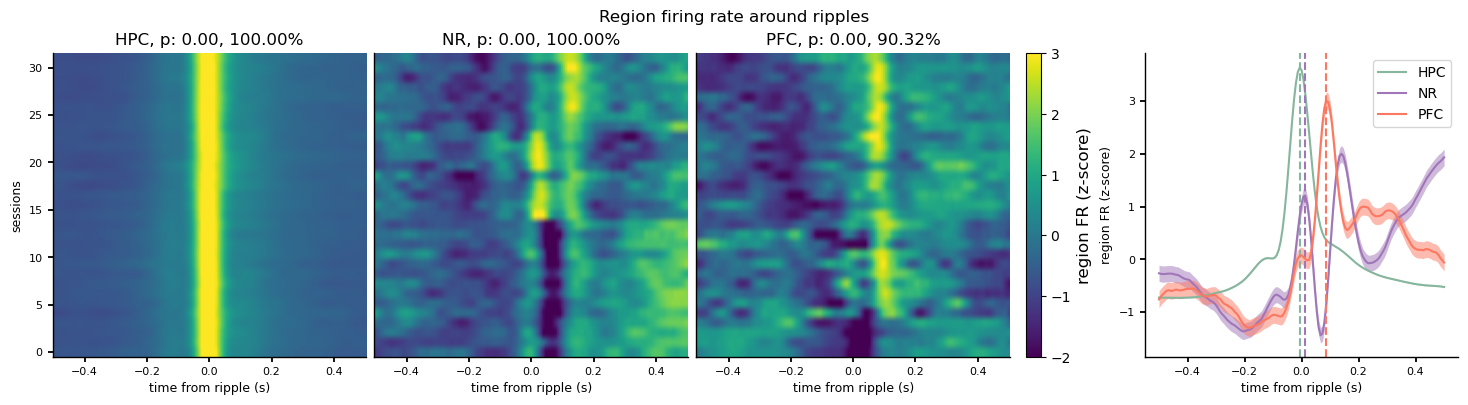

In [106]:
# average across ripples and see effect
do_surrogate = False
signif_perc = np.array([d.attrs['p_val'] for d in fr_data]) # sessions x regs
for i in range(3):
    _, signif_perc[:,i] = fma.analysis.holmBonferroni(signif_perc[:,i],return_reject=True)
signif_perc = signif_perc.mean(axis=0)
fig, axs = fma.plotting.makeFigure(f'Region firing rate around ripples{do_surrogate*', surrogate'}',[1,4],[37,10])
peak_ind = [0,1,0]
peak_time = []
for i, r in enumerate(fr_avrg['region'].values):
    # PETH matrix
    reg_data = fr_avrg.sel(region=r,shuffle=do_surrogate)
    im = fma.plotting.plotColorMap(reg_data.values,zscore=1,vmin=-2,vmax=3,ax=axs[i],x=reg_data['time'])
    axs[i].set_title(f'{r.upper()}, p: {pval_fr[r]:.2f}, {signif_perc[i]*100:.2f}%')
    axs[i].set_xlabel('time from ripple (s)')
    # average PETH
    fma.plotting.semPlot(reg_data['time'],fr_cat.sel(region=r,shuffle=do_surrogate),zscore=True,color=isru.paperColors(i),label=str(r.item().upper()),ax=axs[-1])
    peaks, peak_prop = sp.signal.find_peaks(fr_cat.sel(region=r,shuffle=do_surrogate).mean(dim='ripple'),height=(None,None))
    sort_ind = np.argsort(peak_prop['peak_heights'])
    peak_time.append(reg_data['time'][peaks[sort_ind[-1-peak_ind[i]]]])
    axs[-1].axvline(peak_time[i],ls='--',color=isru.paperColors(i))
    if i != 0:
        axs[i].set_yticks([])
        print(f'HPC-{r.upper()}: {(peak_time[i]-peak_time[0]).item()} s')
cb = plt.colorbar(im)
cb.set_label('region FR (z-score)',fontsize=12)
axs[0].set_ylabel('sessions')
axs[-1].set_xlabel('time from ripple (s)'), axs[-1].set_ylabel('region FR (z-score)'), axs[-1].legend();
fma.plotting.saveFigure(fig,'/mnt/hubel-data-103/Pietro/ReuSlowRythm/Results/FinalFigures/ISRipplesSpindles/3h_region_fr',['svg','png'])

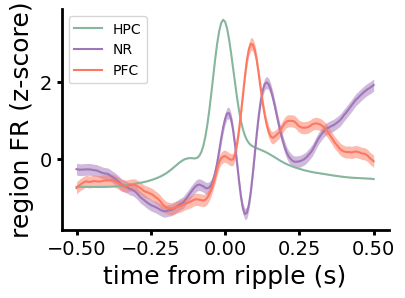

In [ ]:
# Figure poster
do_surrogate = False
fig, axs = fma.plotting.makeFigure('',size=[4,3],format='poster')
peak_ind = [0,1,0]
peak_time = []
for i, r in enumerate(fr_avrg['region'].values):
    reg_data = fr_avrg.sel(region=r,shuffle=do_surrogate)
    # average PETH
    fma.plotting.semPlot(reg_data['time'],fr_cat.sel(region=r,shuffle=do_surrogate),zscore=True,color=isru.paperColors(i),label=str(r.item().upper()),ax=axs[-1])
axs[-1].set_xlabel('time from ripple (s)'), axs[-1].set_ylabel('region FR (z-score)'), axs[-1].legend();
fma.plotting.saveFigure(fig,'/mnt/hubel-data-103/Pietro/ReuSlowRythm/Results/PosterFigures/rip_region_peth','svg')

3. correlation around ripples

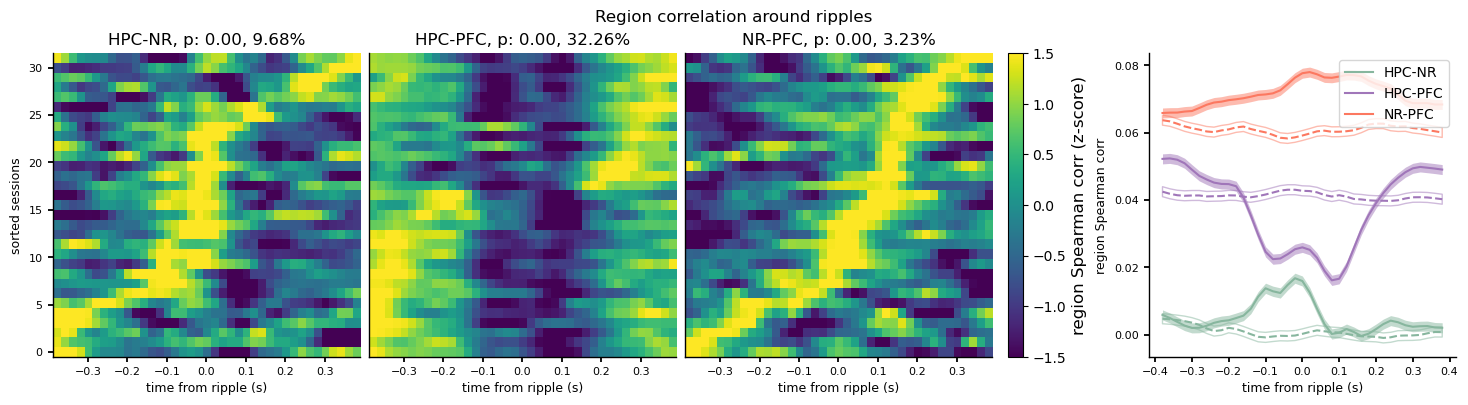

In [107]:
# average across ripples and see effect
do_surrogate = False
signif_perc = np.array([d.attrs['p_val'] for d in dfc_data]) # sessions x regs
for i in range(3):
    _, signif_perc[:,i] = fma.analysis.holmBonferroni(signif_perc[:,i],return_reject=True)
signif_perc = signif_perc.mean(axis=0)
fig, axs = fma.plotting.makeFigure(f'Region correlation around ripples{do_surrogate*', surrogate'}',[1,4],[37,10])
vmin = [-1.5,-1.5,-1.5]
vmax = [1.5,1.5,1.5]
for i, r in enumerate(dfc_avrg['region'].values):
    # PETH matrix
    reg_data = dfc_avrg.sel(region=r,shuffle=do_surrogate)
    im = fma.plotting.plotColorMap(reg_data.values,zscore=1,sortby='peak',vmin=vmin[i],vmax=vmax[i],ax=axs[i],x=reg_data['time'])
    axs[i].set_title(f'{r.upper()}, p: {pval_dfc[r]:.2f}, {signif_perc[i]*100:.2f}%')
    axs[i].set_xlabel('time from ripple (s)')
    # average PETH
    fma.plotting.semPlot(reg_data['time'],dfc_cat.sel(region=r,shuffle=True),zscore=False,color=isru.paperColors(i),lprop={'ls':'--'},
                         aprop={'lw':1,'ec':isru.paperColors(i),'fc':'none'},ax=axs[-1])
    fma.plotting.semPlot(reg_data['time'],dfc_cat.sel(region=r,shuffle=False),zscore=False,color=isru.paperColors(i),label=str(r.upper()),ax=axs[-1])
    if i != 0:
        axs[i].set_yticks([])
cb = plt.colorbar(im)
cb.set_label('region Spearman corr (z-score)',fontsize=12)
axs[0].set_ylabel('sorted sessions')
axs[-1].set_xlabel('time from ripple (s)'), axs[-1].set_ylabel('region Spearman corr'), axs[-1].legend(loc='upper right');
fma.plotting.saveFigure(fig,'/mnt/hubel-data-103/Pietro/ReuSlowRythm/Results/FinalFigures/ISRipplesSpindles/3i_region_corr',['svg','png'])

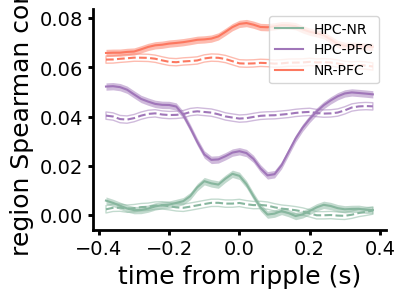

In [19]:
# Figure poster
do_surrogate = False
fig, axs = fma.plotting.makeFigure('',size=[4,3],format='poster')
for i, r in enumerate(dfc_avrg['region'].values):
    reg_data = dfc_avrg.sel(region=r,shuffle=do_surrogate)
    # average PETH
    fma.plotting.semPlot(reg_data['time'],dfc_cat.sel(region=r,shuffle=True),zscore=False,color=isru.paperColors(i),lprop={'ls':'--'},
                         aprop={'lw':1,'ec':isru.paperColors(i),'fc':'none'},ax=axs[-1])
    fma.plotting.semPlot(reg_data['time'],dfc_cat.sel(region=r,shuffle=False),zscore=False,color=isru.paperColors(i),label=str(r.upper()),ax=axs[-1])
axs[-1].set_xlabel('time from ripple (s)'), axs[-1].set_ylabel('region Spearman corr'), axs[-1].legend(loc='upper right');
fma.plotting.saveFigure(fig,'/mnt/hubel-data-103/Pietro/ReuSlowRythm/Results/PosterFigures/rip_region_corr','svg')

Pspyke: su finestre temporali si può valutare nwueon-level correlazioni, magari intporno a ripples

Come H0 potrei guardare se momenti di burst in HPC senza ripples sono risultati simili

3. test from "Statistical analysis of a stimulus-specific network" tutorial

In [ ]:
import frites.dataset as fd
import frites.workflow as fw

In [20]:
data_avrg = [d.groupby('ripple').mean(dim='ripple') for d in data]

In [30]:
ds = fd.DatasetEphy(data_avrg.copy(),y='ripple',times='time',roi='region')
wf = fw.WfMi(mi_type='cd',inference='ffx')
mi, pv = wf.fit(ds,n_perm=200,n_jobs=1,random_state=0)

Definition of an electrophysiological dataset
    Dataset composed of 31 subjects / sessions
    At least False subjects / roi required
    Supported MI definition I(x; y (discret)) (cd)
Gaussian Copula Mutual Information Estimator (mi_type=cd, copnorm=False, biascorrect=True, demeaned=False)
Definition of a non-parametric statistical workflow
Workflow for computing mutual information (inference=ffx, mi_type=cd, copnorm=True)
    Evaluate true and permuted mi (n_perm=200, n_jobs=1)


  0%|          | Estimating MI : 0/3 [00:00<?,       ?it/s]

    Fixed-effect inference (FFX)
    Cluster forming threshold (tail=1; alpha=0.05; tfce=None)
    Inference at cluster-level
    Cluster detection (threshold=0.04513813182711601; tail=1)


In [31]:
def plot_mi(mi, pv):
    # figure definition
    n_subs = len(mi['roi'].data)
    space_single_sub = 4
    fig, gs  = plt.subplots(1, 3, #sharex='all', sharey='all',
                            figsize=(n_subs * space_single_sub, 4))

    for n_r, r in enumerate(mi['roi'].data):
        # select mi and p-values for a single roi
        mi_r, pv_r = mi.sel(roi=r), pv.sel(roi=r)
        # set to nan when it's not significant
        mi_r_s = mi_r.copy()
        mi_r_s[pv_r >= .05] = np.nan
        print(np.isnan(mi_r_s.values).all())

        # significant = red; non-significant = black
        plt.sca(gs[n_r])
        plt.plot(mi['times'].data, mi_r, lw=1, color='k')
        plt.plot(mi['times'].data, mi_r_s, lw=3, color='red')
        plt.xlabel('Times'), plt.ylabel('MI (bits)')
        plt.title(r.upper())
        plt.axvline(0, lw=2, color='k')

    return plt.gcf()

False
True
True


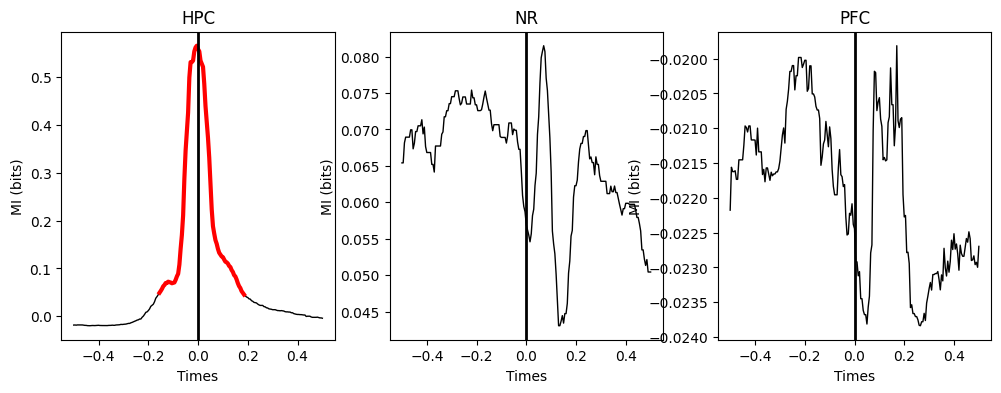

In [32]:
plot_mi(mi, pv)
plt.show()

In [ ]:
# compute dFC on sliding windows

#data_set[data_set==0] = data_set[data_set!=0].min() / 2
dfc = fc.conn_dfc(data_set,times=t,roi=np.arange(len(R.ids)),win_sample=sl_windows,estimator=fe.CorrEstimator('spearman'))
#dt = 20
#lag = 3
#t0 = np.arange(lag,t.size-dt,1)
#gc = fc.conn_covgc(data_set,dt,lag,t0,times=t,roi=np.arange(len(R.ids)))
# takes the mean over trials
#dfc_m = dfc.mean('trials').squeeze()

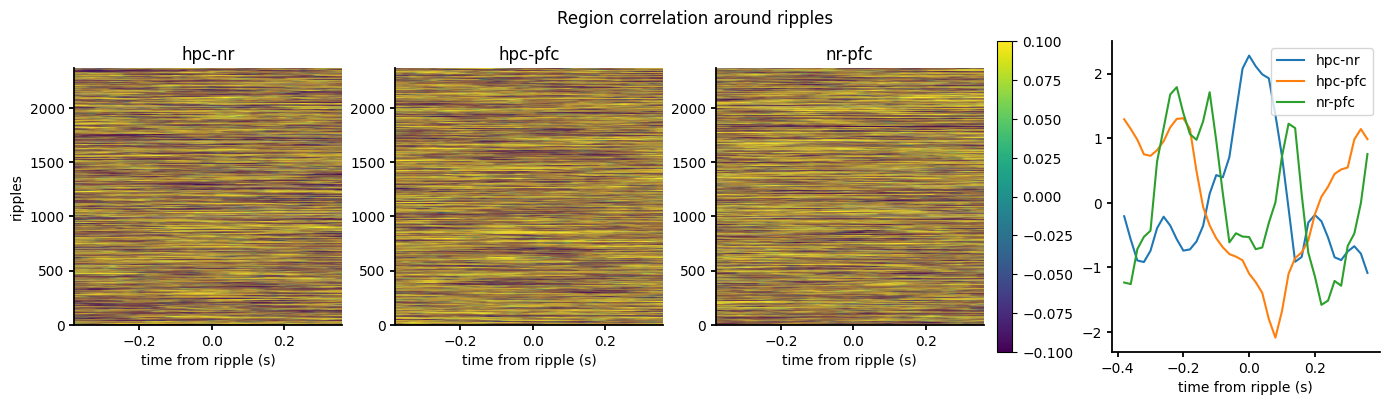

In [76]:
fig, axs = fma.plotting.makeFigure('Region correlation around ripples',[1,4],[35,10])
titles = ['hpc-nr','hpc-pfc','nr-pfc']
for i, r in enumerate(R.ids):
    # sorted PETH matrix
    im = axs[i].imshow(dfc[:,i,:],aspect=.0003,vmin=-.1,vmax=.1,origin='lower',extent=[sl_time[0],sl_time[-1],0,dfc.shape[0]])
    axs[i].set_title(titles[i])
    axs[i].set_xlabel('time from ripple (s)')
    # average PETH
    axs[-1].plot(sl_time,spst.zscore(np.mean(dfc,axis=0)[i]),label=titles[i])
axs[0].set_ylabel('ripples')
axs[-1].set_xlabel('time from ripple (s)')
axs[-1].legend()
plt.colorbar(im);

In [ ]:
# try proving that activity of regions is modulated by ripples

In [77]:
import xarray as xr

from frites.simulations import StimSpecAR

ar_type = 'hga'
n_subjects = 5
n_stim = 2
n_epochs = 100
n_std = 1

ss_obj = StimSpecAR()
# generate the data
x = []
for n_s in range(n_subjects):
    # generate nodes x and y
    _x = ss_obj.fit(ar_type=ar_type, n_epochs=n_epochs, n_stim=n_stim,
                    n_std=n_std, random_state=n_s)
    trials, times = _x['trials'].data, _x['times'].data
    # generate pure noise node z
    rnd = np.random.RandomState(n_s)
    _z = rnd.uniform(-.5, .5, (len(trials), 1, len(times)))
    _z = xr.DataArray(_z, dims=('trials', 'roi', 'times'),
                      coords=(trials, np.array(['z']), times))
    # concatenate the three nodes
    _x = xr.concat((_x, _z), 'roi')

    x += [_x]

# get times and roi
times = _x['times'].data
roi = _x['roi'].data

Evoked HGA AR model (n_times=300, n_epochs=100, n_stim=2, random_state=0)
Evoked HGA AR model (n_times=300, n_epochs=100, n_stim=2, random_state=1)
Evoked HGA AR model (n_times=300, n_epochs=100, n_stim=2, random_state=2)
Evoked HGA AR model (n_times=300, n_epochs=100, n_stim=2, random_state=3)
Evoked HGA AR model (n_times=300, n_epochs=100, n_stim=2, random_state=4)


In [93]:
x[1]

<xarray.DataArray (trials: 200, roi: 3, times: 300)> Size: 1MB
array([[[ 0.36321467, -0.13679289, -0.11810279, ...,  0.19599185,
         -0.15484203,  0.08456095],
        [-0.09318989, -0.01258165, -0.47766797, ..., -0.18922879,
         -0.11530714, -0.13849856],
        [-0.082978  ,  0.22032449, -0.49988563, ..., -0.42037392,
          0.48281711, -0.31838715]],

       [[ 0.46192319, -0.32896069, -0.18563208, ...,  0.29767235,
         -0.01493369,  0.30521337],
        [ 0.19472591,  0.13255563, -0.24581035, ..., -0.12734197,
         -0.17166518, -0.38615153],
        [ 0.3118587 ,  0.37496164,  0.18841325, ..., -0.1229174 ,
         -0.47337212, -0.38907963]],

       [[-0.23992211,  0.11072083, -0.21288756, ..., -0.38912125,
         -0.00619822, -0.33597135],
        [ 0.13498504, -0.01780211, -0.04724201, ..., -0.45923156,
         -0.11540812, -0.07655504],
        [ 0.17456402,  0.29977654, -0.41947047, ...,  0.0527676 ,
          0.38913109, -0.14504715]],
...
       [[-0.3229614 , -0.09844539,  0.31461665, ..., -0.01729507,
          0.11629631,  0.00609936],
        [ 0.0045025 , -0.21572462, -0.01494224, ...,  0.50345331,
         -0.10797712, -0.03103964],
        [ 0.20560466, -0.06128324,  0.00160802, ...,  0.29347544,
          0.20352322,  0.40773371]],

       [[-0.08088405,  0.09331632, -0.17369925, ..., -0.35982983,
          0.03987438,  0.01410009],
        [-0.10325231, -0.06080463, -0.15856697, ..., -0.35107513,
         -0.40246986, -0.4020219 ],
        [-0.14340104,  0.17774542,  0.13287908, ...,  0.3696809 ,
         -0.43937177,  0.06717961]],

       [[ 0.3485956 ,  0.14693277,  0.03307338, ...,  0.42615508,
          0.14013692, -0.09853784],
        [ 0.01926154,  0.24151167, -0.16960979, ..., -0.26948693,
         -0.25519503, -0.22926819],
        [ 0.09835672, -0.32011141, -0.12734137, ...,  0.4963921 ,
          0.03686152, -0.25038015]]])
Coordinates:
  * trials   (trials) int64 2kB 1 1 1 1 1 1 1 1 1 1 1 ... 2 2 2 2 2 2 2 2 2 2 2
  * roi      (roi) <U1 12B 'x' 'y' 'z'
  * times    (times) float64 2kB -0.5 -0.495 -0.49 -0.485 ... 0.985 0.99 0.995
Attributes:
    n_stim:    2
    n_std:     1
    ar_type:   hga
    stimulus:  [1 2]